In [2]:
import sqlite3
db_file = "Weather_Data_3.db"
conn = sqlite3.connect(db_file)

In [1]:
import sqlite3
db_file = "Weather_Data_3.db"

try: 
    conn = sqlite3.connect(db_file)
    conn.row_factory = sqlite3.Row
    cur = conn.cursor()
    cur.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [r["name"] for r in cur.fetchall()]
    print(f"Connected to {db_file} - tables: {tables or '(<no tables>)'}")
except sqlite3.Error as e:
    print("SQLite error:", e)
    conn = None
    cur = None

Connected to Weather_Data_3.db - tables: ['karlsruhe_weather_11_2025', 'karlsruhe_weather_10_2025', 'karlsruhe_weather_09_2025']


In [2]:
import pandas as pd
query = "SELECT * FROM karlsruhe_weather_09_2025;"
tabelle = pd.read_sql_query(query, conn)
tabelle.head(5)

,time,temp,prcp,snow,wdir,wspd,tsun
0,2025-09-01 00:00:00,16.3,0.3,None,146.0,5.5,0
1,2025-09-01 01:00:00,16.2,0.7,None,159.0,5.5,0
2,2025-09-01 02:00:00,16.1,0.6,None,179.0,7.4,0
3,2025-09-01 03:00:00,16.1,0.4,None,202.0,7.4,0
4,2025-09-01 04:00:00,15.7,0.7,None,201.0,7.4,0


In [3]:
query_top20 = """
SELECT time as Uhrzeit, temp as Temperatur
FROM karlsruhe_weather_09_2025
ORDER BY time DESC
LIMIT 23
;
"""
top20 = pd.read_sql_query(query_top20, conn)
top20


,Uhrzeit,Temperatur
0,2025-09-30 23:00:00,10.2
1,2025-09-30 22:00:00,11.1
2,2025-09-30 21:00:00,12.1
3,2025-09-30 20:00:00,12.7
4,2025-09-30 19:00:00,13.8
5,2025-09-30 18:00:00,15.6
6,2025-09-30 17:00:00,15.7
7,2025-09-30 16:00:00,16.1
8,2025-09-30 15:00:00,16.0
9,2025-09-30 14:00:00,15.7


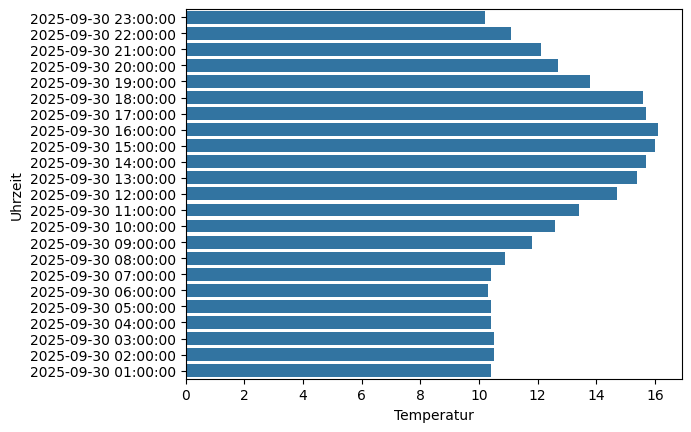

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=top20, x="Temperatur", y="Uhrzeit")
plt.show()

In [17]:
query = """SELECT * 
FROM karlsruhe_weather_09_2025
ORDER BY time ASC
LIMIT 24;"""
df = pd.read_sql_query(query, conn)
df.head(24)

,time,temp,prcp,snow,wdir,wspd,tsun
0,2025-09-01 00:00:00,16.3,0.3,None,146.0,5.5,0
1,2025-09-01 01:00:00,16.2,0.7,None,159.0,5.5,0
2,2025-09-01 02:00:00,16.1,0.6,None,179.0,7.4,0
3,2025-09-01 03:00:00,16.1,0.4,None,202.0,7.4,0
4,2025-09-01 04:00:00,15.7,0.7,None,201.0,7.4,0
5,2025-09-01 05:00:00,16.0,0.6,None,200.0,7.4,0
6,2025-09-01 06:00:00,15.7,0.6,None,195.0,9.3,0
7,2025-09-01 07:00:00,16.5,0.6,None,200.0,9.3,1
8,2025-09-01 08:00:00,16.9,0.5,None,202.0,9.3,2
9,2025-09-01 09:00:00,16.8,0.5,None,209.0,11.1,0


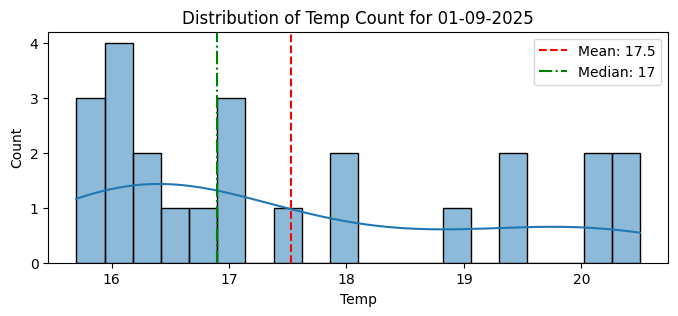

In [18]:
# plot distribution of temp
plt.figure(figsize=(8, 3))
sns.histplot(df['temp'], bins=20, kde=True, color='C0')
mean_temp = df['temp'].mean()
median_temp = df['temp'].median()
plt.axvline(mean_temp, color='red', linestyle='--', label=f"Mean: {mean_temp:.1f}")
plt.axvline(median_temp, color='green', linestyle='-.', label=f"Median: {median_temp:.0f}")
plt.title("Distribution of Temp Count for 01-09-2025")
plt.xlabel("Temp")
plt.ylabel("Count")
plt.legend()
plt.show()

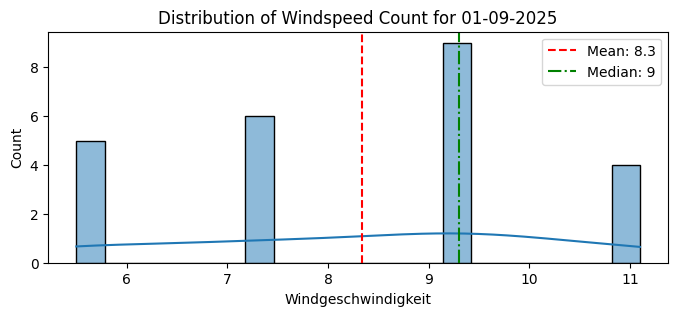

In [19]:
# plot distribution of wspd
plt.figure(figsize=(8, 3))
sns.histplot(df['wspd'], bins=20, kde=True, color='C0')
mean_temp = df['wspd'].mean()
median_temp = df['wspd'].median()
plt.axvline(mean_temp, color='red', linestyle='--', label=f"Mean: {mean_temp:.1f}")
plt.axvline(median_temp, color='green', linestyle='-.', label=f"Median: {median_temp:.0f}")
plt.title("Distribution of Windspeed Count for 01-09-2025")
plt.xlabel("Windgeschwindigkeit")
plt.ylabel("Count")
plt.legend()
plt.show()

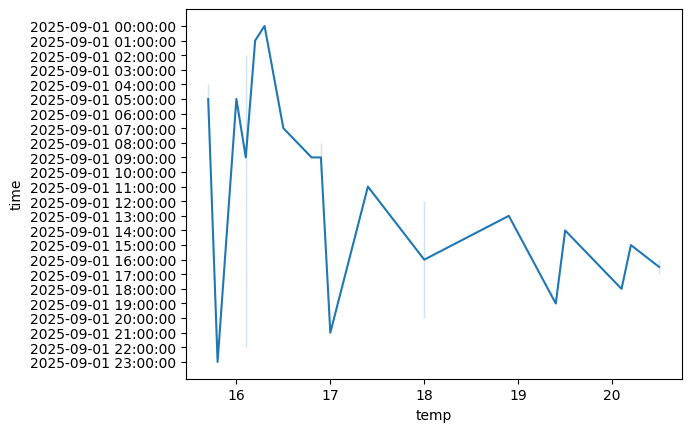

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data=df, x="temp", y="time")
#sns.catplot(data=df, x="temp", y="time")
#sns.boxplot(data=df, x="temp", y="time")
#sns.barplot(data=df, x="temp", y="time")
plt.show()

In [27]:
query = '''
SELECT temp as Temperatur, time as Datum, prcp as Regen
FROM karlsruhe_weather_09_2025
ORDER BY time ASC
LIMIT 24;'''

df = pd.read_sql_query(query, conn)
df.tail(23)

,Temperatur,Datum,Regen
1,16.2,2025-09-01 01:00:00,0.7
2,16.1,2025-09-01 02:00:00,0.6
3,16.1,2025-09-01 03:00:00,0.4
4,15.7,2025-09-01 04:00:00,0.7
5,16.0,2025-09-01 05:00:00,0.6
6,15.7,2025-09-01 06:00:00,0.6
7,16.5,2025-09-01 07:00:00,0.6
8,16.9,2025-09-01 08:00:00,0.5
9,16.8,2025-09-01 09:00:00,0.5
10,16.9,2025-09-01 10:00:00,0.5


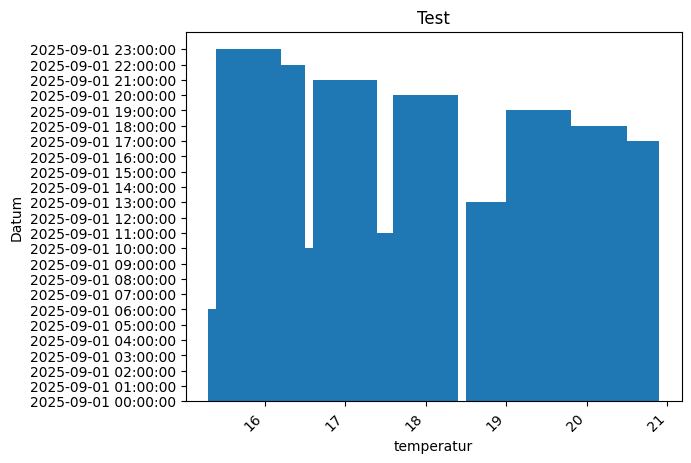

In [28]:
plt.bar(df['Temperatur'], df['Datum'], color='C0')
plt.title("Test")
plt.xlabel("temperatur")
plt.ylabel("Datum")
plt.xticks(rotation=45, ha='right')
plt.show()

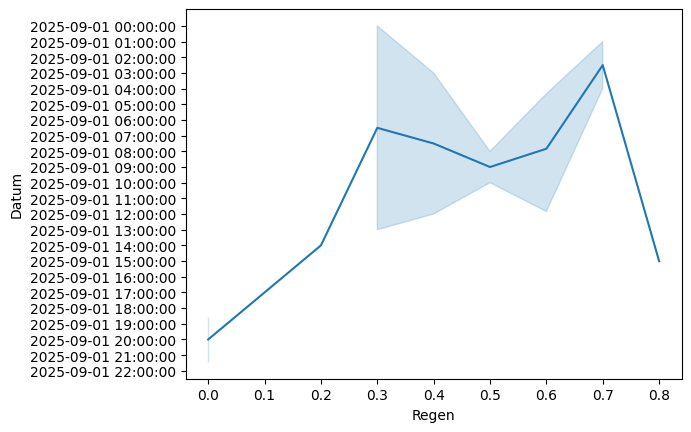

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data=df, x="Regen", y="Datum")
plt.show()